In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.chdir('../')

import pickle
from pathlib import Path
import time
import glob
from tqdm import tqdm

import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split, KFold
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from pytorch_lightning.core.lightning import LightningModule
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import TensorBoardLogger

from utils.config_dataset import *
from utils.data_io import load_train_test_dataset, pickle_load
from utils.ClassMonoModel import AE_PHYSIO, AE_MED_PHYSIO
from utils.ClassSOM import VASO_PHYSIO_PRED

RANDOMSEED=2024
torch.manual_seed(RANDOMSEED)
np.random.seed(RANDOMSEED)

import warnings
warnings.filterwarnings("ignore")

# limit CPU cores used by the script
os.environ["OMP_NUM_THREADS"] = "32" # export OMP_NUM_THREADS=1
os.environ["OPENBLAS_NUM_THREADS"] = "32" # export OPENBLAS_NUM_THREADS=1
os.environ["MKL_NUM_THREADS"] = "32" # export MKL_NUM_THREADS=1
os.environ["VECLIB_MAXIMUM_THREADS"] = "32" # export VECLIB_MAXIMUM_THREADS=1
os.environ["NUMEXPR_NUM_THREADS"] = "32" # export NUMEXPR_NUM_THREADS=1

In [2]:
base_path = 'processed-merge-v3/'

# load AE model
# model_path = 'models/AE_PHYSIO/VASO-TCN-168hidden-0.1dropout-32-0.0005/version_0'
# model_file = os.path.join(model_path, 'epoch151-val_loss_pred0.05374.ckpt')

model_path = 'models/AE_MED_PHYSIO/VASO-TCN-168hidden-0.1dropout-16-0.0005/version_3'
model_file = os.path.join(model_path, 'epoch175-val_loss0.61018.ckpt')
model_type = 'AE_MED_PHYSIO'

# model_path = 'models/VASO_PHYSIO_PRED/VASO-CNN-196hidden-0.1dropout-16-0.0005/version_0'
# model_file = os.path.join(model_path, 'epoch75-val_loss_pred0.05408.ckpt')
# model_type = 'VASO_PHYSIO_PRED'

config_file = os.path.join(model_path, "model_config.p")
config = pickle_load(config_file)
device = 'cuda'

if model_type == 'AE_PHYSIO':
    model = AE_PHYSIO.load_from_checkpoint(checkpoint_path=model_file, config=config)  # without considering med effect
elif model_type == 'AE_MED_PHYSIO':
    model =AE_MED_PHYSIO.load_from_checkpoint(checkpoint_path=model_file, config=config)
elif model_type == 'VASO_PHYSIO_PRED':
    model = VASO_PHYSIO_PRED.load_from_checkpoint(checkpoint_path=model_file, config=config)
model.to(device)
model.eval()

# Load dataset
DATA = load_train_test_dataset(
    batchsize=32,
    sample_dict_file='sample_dict_vasopressor_filtered70.p',
    type='vaso',
    RANDOMSEED=RANDOMSEED, norm=True, smooth=True, interpolate=True,
    data_path=base_path
)
pid_valid = DATA['pid_valid']
norm_params = DATA['norm_params']
norm_params_info = DATA['norm_params_info']
patient_info = DATA['patient_info']
dataset_train = DATA['dataset_train']
dataset_val = DATA['dataset_val']
dataset_test = DATA['dataset_test']
# loader_train = DATA['loader_train']
# loader_val = DATA['loader_val']
loader_test = DATA['loader_test']

loader_train = DataLoader(torch.utils.data.ConcatDataset([dataset_train, dataset_val]), 
                          batch_size=32, shuffle=False, num_workers=32)

def de_norm(data, col, norm_params=norm_params):
    norm_min = norm_params[col].loc['0.1%']
    norm_max = norm_params[col].loc['99.9%']
    data_ = data * (norm_max - norm_min) + norm_min
    return data_

Loading dataset
SAMPLE TRAIN: 1567, SAMPLE VAL: 392, SAMPLE TEST: 490


In [3]:
X_reconstructed = {'train':[], 'test':[]}
X_pred = {'train':[], 'test':[]}
X_enc = {'train':[], 'test':[]}
X_enc_next = {'train':[], 'test':[]}

for X in tqdm(loader_train):
    for k in X:
        if type(X[k]) is dict:
            for j in X[k]:
                X[k][j] = torch.Tensor(X[k][j]).to(device)
        else:
            X[k] = torch.Tensor(X[k]).to(device)
    X_, X_next, enc, enc_next, _ = model(X)
    X_reconstructed['train'].append(X_.cpu().detach().numpy())
    X_pred['train'].append(X_next.cpu().detach().numpy())
    X_enc['train'].append(enc.cpu().detach().numpy())
    X_enc_next['train'].append(enc_next.cpu().detach().numpy())
    
    
for X in tqdm(loader_test):
    for k in X:
        if type(X[k]) is dict:
            for j in X[k]:
                X[k][j] = torch.Tensor(X[k][j]).to(device)
        else:
            X[k] = torch.Tensor(X[k]).to(device)
    X_, X_next, enc, enc_next, _ = model(X)
    X_reconstructed['test'].append(X_.cpu().detach().numpy())
    X_pred['test'].append(X_next.cpu().detach().numpy())
    X_enc['test'].append(enc.cpu().detach().numpy())
    X_enc_next['test'].append(enc_next.cpu().detach().numpy())
    
X_reconstructed['train'] = np.concatenate(X_reconstructed['train'], axis=0)
X_pred['train'] = np.concatenate(X_pred['train'], axis=0)
X_enc['train'] = np.concatenate(X_enc['train'], axis=0)
X_enc_next['train'] = np.concatenate(X_enc_next['train'], axis=0)

    
X_reconstructed['test'] = np.concatenate(X_reconstructed['test'], axis=0)
X_pred['test'] = np.concatenate(X_pred['test'], axis=0)
X_enc['test'] = np.concatenate(X_enc['test'], axis=0)
X_enc_next['test'] = np.concatenate(X_enc_next['test'], axis=0)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:06<00:00,  2.42it/s]


In [4]:
X_reconstructed['train'].shape, X_reconstructed['test'].shape

((1959, 90, 7), (490, 90, 7))

In [5]:
meds = ['norepinephrine', 'epinephrine', 'dobutamine']

data_raw = {
    'train': {med: [] for med in meds},
    'test': {med: [] for med in meds},
}
data_pred = {
    'train': {med: [] for med in meds},
    'test': {med: [] for med in meds},
}
data_enc = {
    'train': {med: [] for med in meds},
    'test': {med: [] for med in meds},
}
data_labels = {
    'train': {
        med: {
            "age": [],
            "los": [],
            "discharge_status": [],
            "circ_failure": [],
            "resp_failure": [],
        } for med in meds
    },
    'test': {
        med: {
            "age": [],
            "los": [],
            "discharge_status": [],
            "circ_failure": [],
            "resp_failure": [],
        } for med in meds
    }
}
for idx, sample in tqdm(enumerate(torch.utils.data.ConcatDataset([dataset_train, dataset_val]))):
    med = meds[np.where(sample['med_label']==1)[0].item()]
    raw = sample['data']
    raw[np.where(raw==-1)] = np.nan
    data_raw['train'][med].append(raw[None,:,:])
    data_pred['train'][med].append(np.concatenate((X_reconstructed['train'][idx], 
                                                   X_pred['train'][idx]), axis=0)[None,:,:])
    data_enc['train'][med].append(np.concatenate((X_enc['train'].reshape(X_enc['train'].shape[0], -1)[idx], 
                                                  X_enc_next['train'][idx]))[None,:])
    for k in data_labels['train'][med]:
        try:
            data_labels['train'][med][k].append(sample['info'][k])
        except:
            data_labels['train'][med][k].append(sample[k])
            
for idx, sample in tqdm(enumerate(dataset_test)):
    med = meds[np.where(sample['med_label']==1)[0].item()]
    raw = sample['data']
    raw[np.where(raw==-1)] = np.nan
    data_raw['test'][med].append(raw[None,:,:])
    data_pred['test'][med].append(np.concatenate((X_reconstructed['test'][idx], 
                                                  X_pred['test'][idx]), axis=0)[None,:,:])
    data_enc['test'][med].append(np.concatenate((X_enc['test'].reshape(X_enc['test'].shape[0], -1)[idx], 
                                                 X_enc_next['test'][idx]))[None,:])
    for k in data_labels['test'][med]:
        try:
            data_labels['test'][med][k].append(sample['info'][k])
        except:
            data_labels['test'][med][k].append(sample[k])

1959it [04:09,  7.84it/s]
490it [01:02,  7.87it/s]


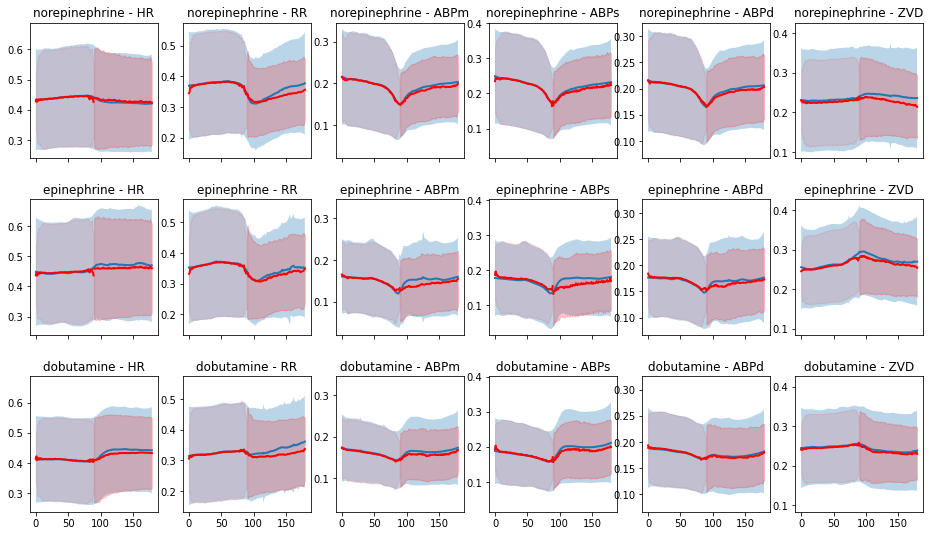

In [6]:
fig, ax = plt.subplots(3, 6, figsize=(16,9), sharex=True, sharey='col')
plt.subplots_adjust(hspace=.3, wspace=.2)
physio_plot = [
    'HR',
    'RR',
    'ABPm',
    'ABPs',
    'ABPd',
    'ZVD',
#     'OUTurine/h',
]

split = 'train'
for i, med in enumerate(MED_BENCHMARK[:3]):
    data = np.concatenate(data_raw[split][med], axis=0)
    mean_raw = np.nanmean(data, axis=0)
    std_raw = np.nanstd(data, axis=0)

    pred = np.concatenate(data_pred[split][med], axis=0)
    mean = pred.mean(0)
    std = pred.std(0)
    for j, physio in enumerate(physio_plot):
        idx_physio = PHYSIO_BENCHMARK.index(physio)
        
        
        ax[i][j].plot(mean_raw[:,idx_physio], linewidth=2);
        ax[i][j].fill_between(range(180), 
                        mean_raw[:,idx_physio]-std_raw[:,idx_physio], 
                        mean_raw[:,idx_physio]+std_raw[:,idx_physio], 
                        alpha=.3)
        
        ax[i][j].plot(range(90), mean[:90,idx_physio], linewidth=2, color='r');
        ax[i][j].fill_between(range(90), 
                        mean[:90,idx_physio]-std[:90,idx_physio], 
                        mean[:90,idx_physio]+std[:90,idx_physio], 
                        alpha=.1, color='r')
        
        ax[i][j].plot(range(90,180), mean[90:,idx_physio], linewidth=2, color='r');
        ax[i][j].fill_between(range(90, 180), 
                        mean[90:,idx_physio]-std[90:,idx_physio], 
                        mean[90:,idx_physio]+std[90:,idx_physio], 
                        alpha=.2, color='r')
        
        
    #     ax.set_ylim(0.2, 0.4)
        ax[i][j].set_title(f'{med} - {physio}')

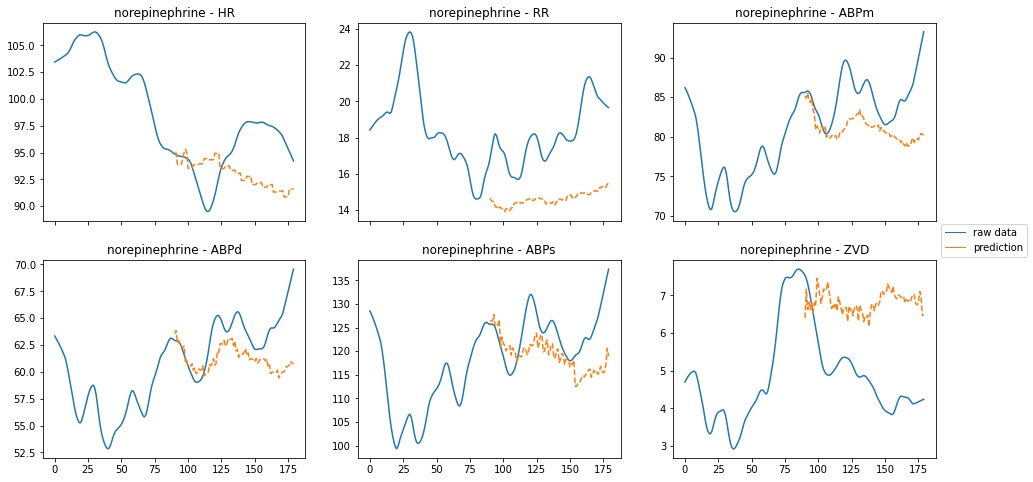

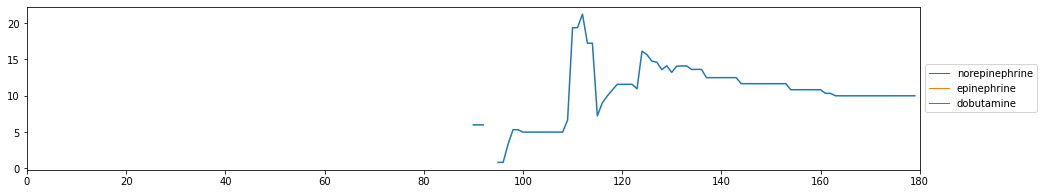

In [113]:
selected_physio = ['HR', 'RR', 'SpO2', 'ABPd', 'ABPm', 'ABPs', 'ZVD']

idx = 99

split = 'test'
x = dataset_test[idx]['data']
x[np.where(x==-1)] = np.nan
x_ = X_reconstructed[split][idx]
x_[np.where(x_==-1)] = np.nan
x_next = X_pred[split][idx]
x_next[np.where(x_next==-1)] = np.nan
meds = ['norepinephrine', 'epinephrine', 'dobutamine']
med = meds[np.where(dataset_train[idx]['med_label']==1)[0].item()]
x_med = dataset_train[idx]['med']
x_med[np.where(x_med==0)] = np.nan

labels = selected_physio

fig, ax = plt.subplots(2,3,figsize=(16,8), sharex=True)
colors = plt.cm.tab10
physio_plot = [
    'HR',
    'RR',
    'ABPm',
    'ABPd',
    'ABPs',
    'ZVD',
]

for i, physio in enumerate(physio_plot):
    idx_physio = PHYSIO_BENCHMARK.index(physio)
    
    x_raw = de_norm(x[:,idx_physio], physio)
    x_pred = de_norm(x_next[:,idx_physio], physio)
    
    ax[i//3][i%3].plot(range(180), x_raw, '-', color=colors(0))
    ax[i//3][i%3].plot(range(90, 180), x_pred, '--', color=colors(1))
    ax[i//3][i%3].set_title(f"{med} - {physio}")
lines = [Line2D([0], [0], color=colors(0), lw=1, label='raw data'), 
         Line2D([0], [0], color=colors(1), lw=1, label='prediction')]
plt.legend(handles = lines, loc='center left', bbox_to_anchor=(1, 1.1));    

    
fig, ax = plt.subplots(1, 1, figsize=(16,3))
lines = []
for med in MED_BENCHMARK[:3]:
    idx_med = MED_BENCHMARK.index(med)
    med_raw =  de_norm(x_med[:, idx_med], med)
    ax.plot(med_raw, label=med, color=colors(idx_med))
    lines.append(Line2D([0], [0], color=colors(idx_med), lw=1, label=med))
ax.legend(handles = lines, loc='center left', bbox_to_anchor=(1, 0.5));
ax.set_xlim(0, 180);

# PCA

In [7]:
from sklearn.decomposition import KernelPCA

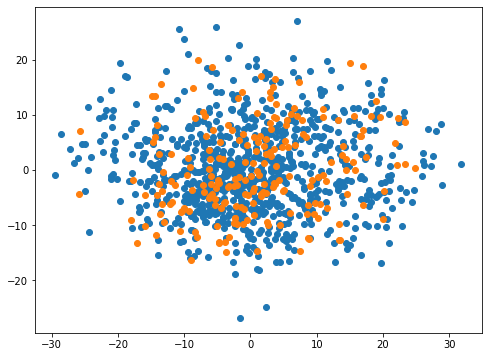

In [8]:
X_train = np.array(data_enc['train']['norepinephrine'])
X_train = X_train.reshape(X_train.shape[0], X_train.shape[2])

X_test = np.array(data_enc['test']['norepinephrine'])
X_test = X_test.reshape(X_test.shape[0], X_test.shape[2])

pca = KernelPCA(n_components=16, kernel='linear', n_jobs=48)
pca.fit(X_train)
# plot_pca_explained_variance(pca)

x_pca_train = pca.transform(X_train)
x_pca_test = pca.transform(X_test)


fig, ax = plt.subplots(1, 1, figsize=(8, 6), sharex=True, sharey=True)
ax.scatter(x_pca_train[:, 0], x_pca_train[:, 1])
ax.scatter(x_pca_test[:, 0], x_pca_test[:, 1])
# ax[1].scatter(x_linear2[:, 0], x_linear2[:, 1])

# MiniSOM


In [9]:
from minisom import MiniSom
from matplotlib.gridspec import GridSpec
%matplotlib inline

In [10]:
print(f'num_feat: {x_pca_train.shape[1]}')
print(f'SOM size: {np.sqrt(5 * np.sqrt(x_pca_train.shape[0]))}')

num_feat: 16
SOM size: 12.048747296278552


In [11]:
som = MiniSom(8, 8, 16, sigma=2., learning_rate=0.5, 
              neighborhood_function='bubble', random_seed=10)
print('Initializing weights...')
# som.pca_weights_init(X_pca)
som.random_weights_init(x_pca_train)
print("Training...")
som.train(x_pca_train, 30,
          random_order=True, verbose=True, use_epochs=True)  # random training
print("\n...ready!")

Initializing weights...
Training...
 [ 25290 / 25290 ] 100% - 0:00:00 left 
 quantization error: 8.443298582928533

...ready!


In [12]:
# idx_sub = np.random.choice(range(len(x_pca)), 1000)
# X_sub = X_pca[idx_sub]
# data_sub = np.array(X_rec[0])[idx_test][idx_sub]

win_map = {
    'train': som.win_map(x_pca_train, return_indices=True),
    'test': som.win_map(x_pca_test, return_indices=True)
}
# win_map_sorted = sorted(win_map.items(), key=lambda item: len(item[1]), reverse=True)

RAW DATA


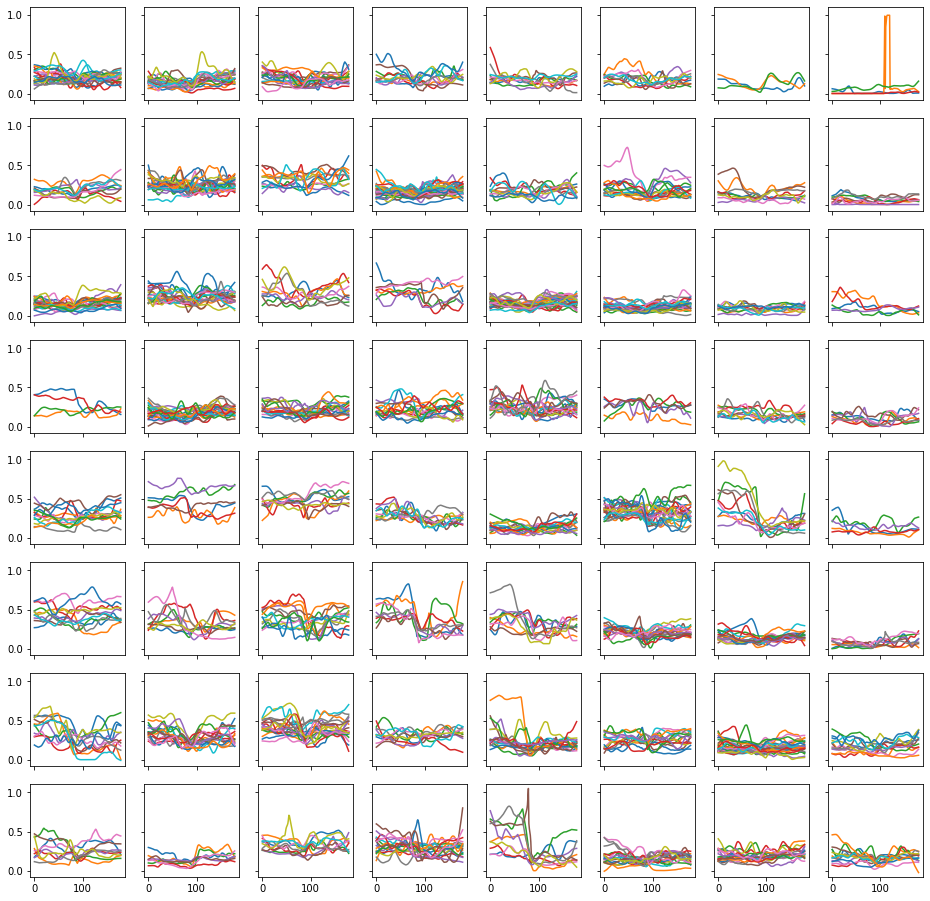

MODEL PREDICTION


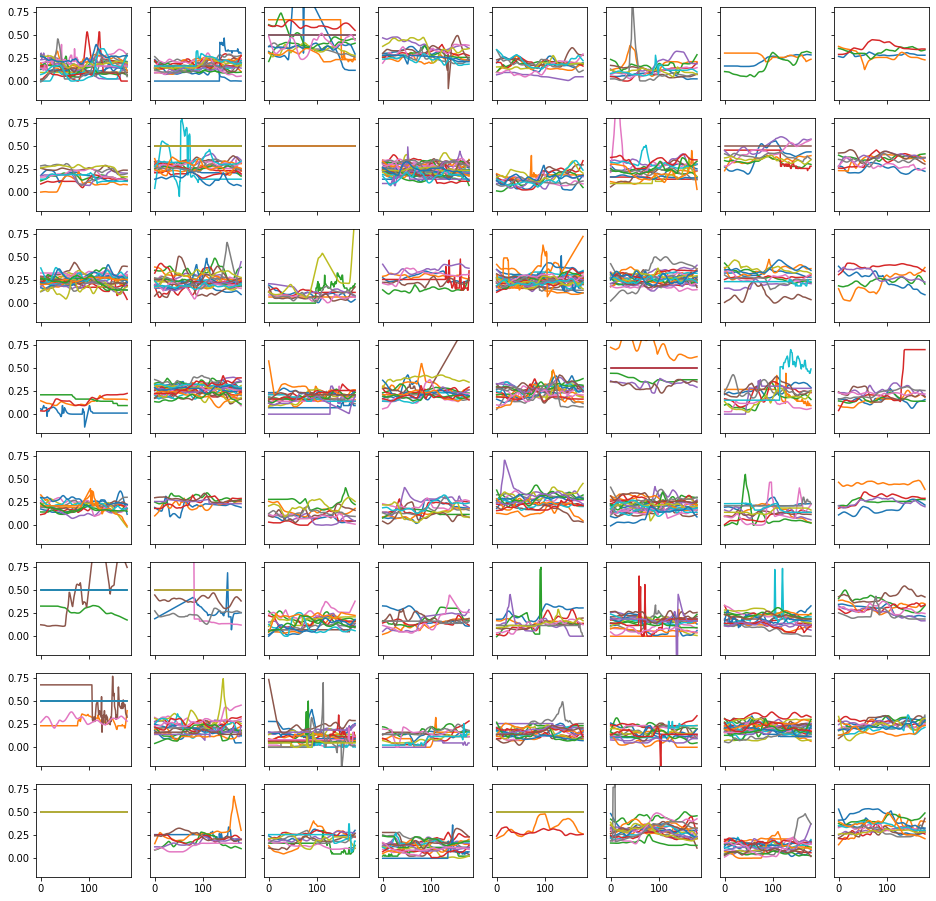

In [78]:
fig, ax = plt.subplots(8,8,figsize=(16,16), sharey=True, sharex=True)
colors = plt.cm.tab20


print('RAW DATA')
split = 'train'
data_plot = np.array(data_raw[split]['norepinephrine']).squeeze()
for k in win_map[split]:
    data_c = data_plot[win_map[split][k]]
    
    for j in range(data_c.shape[0]):
        try:
            ax[k[0]][k[1]].plot(range(180), data_c[j, :, 5])
        except:
            continue
plt.show()
            
print('MODEL PREDICTION')
fig, ax = plt.subplots(8,8,figsize=(16,16), sharey=True, sharex=True)
colors = plt.cm.tab20
ax[0][0].set_ylim(-.2, .8)

split = 'train'
data_plot = np.array(data_raw[split]['norepinephrine']).squeeze()
for k in win_map[split]:
    data_c = data_plot[win_map[split][k]]
    
    for j in range(data_c.shape[0]):
        try:
            ax[k[0]][k[1]].plot(range(180), data_c[j, :, 6])
        except:
            continue
            
# fig, ax = plt.subplots(8,8,figsize=(16,16), sharey=True, sharex=True)
# colors = plt.cm.tab20

# split = 'test'
# data_plot = np.array(data_pred[split]['norepinephrine']).squeeze()
# for k in win_map[split]:
#     data_c = data_plot[win_map[split][k]]
    
#     for j in range(data_c.shape[0]):
#         try:
#             ax[k[0]][k[1]].plot(range(180), data_c[j, :, 5])
#         except:
#             continue
            


In [74]:
label_map = {
    k:{
        'train': {
            l:[] for l in data_labels['train']['norepinephrine']
        }, 
        'test': {
            l:[] for l in data_labels['test']['norepinephrine']
        },
    } for k in win_map['train']
}

for split in win_map:
    for k in win_map[split]:
        idx = win_map[split][k]

        for l in data_labels[split]['norepinephrine']:
            if l == 'los':
                for i in idx:
                    label_map[k][split][l].append(data_labels[split]['norepinephrine'][l][i][-1])
            elif l == 'circ_failure' or l == 'resp_failure':
                for i in idx:
                    label_map[k][split][l].append(int(data_labels[split]['norepinephrine'][l][i].sum() > 1))
            else: 
                label_map[k][split][l] = np.array(data_labels[split]['norepinephrine'][l])[idx].astype(float)

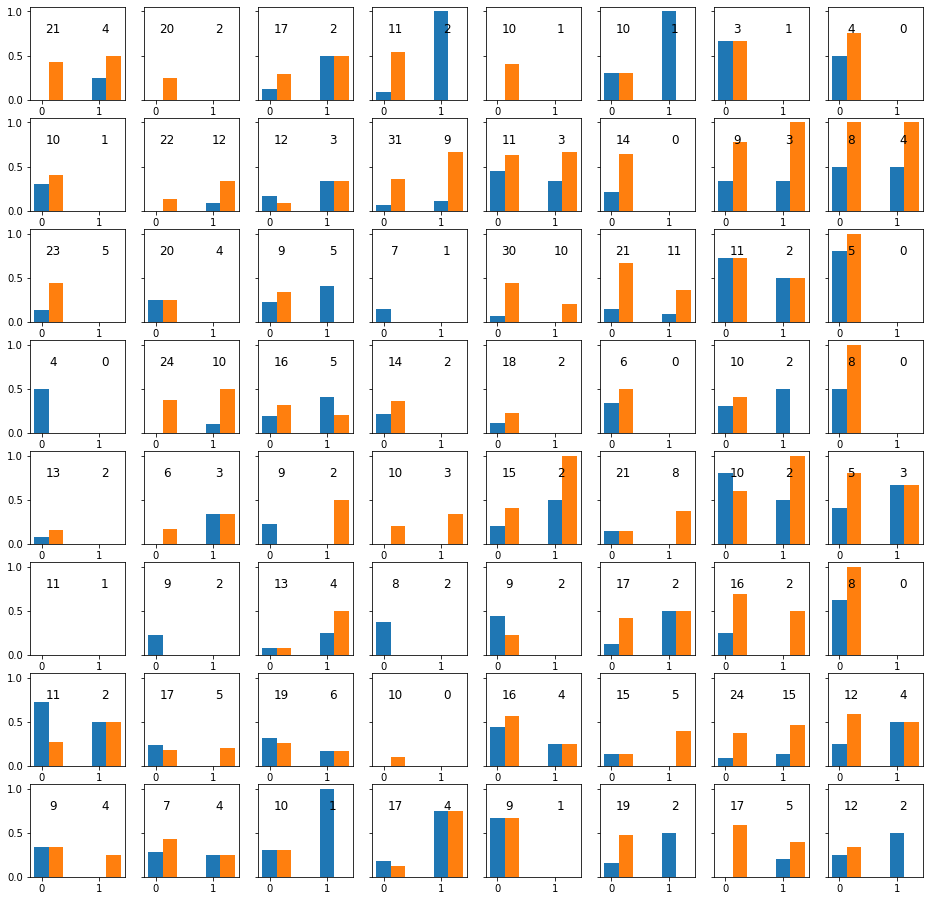

In [43]:
# plot age and mortality
fig, ax = plt.subplots(8,8,figsize=(16,16), sharey=True)
text_kwargs = dict(ha='center', va='center', fontsize=12, color='black')

groups = ("Train", "Test")

for k in label_map:
    if type(k) is int:
        continue
    mortality_train = (label_map[k]['train']['discharge_status']==0).sum() / \
        len(label_map[k]['train']['discharge_status'])
    circ_train = np.array(label_map[k]['train']['circ_failure']).sum() / \
        len(label_map[k]['train']['circ_failure'])
    resp_train = np.array(label_map[k]['train']['resp_failure']).sum() / \
        len(label_map[k]['train']['resp_failure'])
    try:
        mortality_test = (label_map[k]['test']['discharge_status']==0).sum() / \
            len(label_map[k]['test']['discharge_status'])
        circ_test = np.array(label_map[k]['test']['circ_failure']).sum() / \
            len(label_map[k]['test']['circ_failure'])
        resp_test = np.array(label_map[k]['test']['resp_failure']).sum() / \
            len(label_map[k]['test']['resp_failure'])
    except:
        if len(label_map[k]['test']['discharge_status']) == 0:
            mortality_test = 0
            circ_test = 0
            resp_test = 0

    statistics = {
        'death': (mortality_train, mortality_test),
        'circ': (circ_train, circ_test),
#         'resp': (resp_train, resp_test),
    }
    x = np.arange(len(groups))  # the label locations
    width = 0.25  # the width of the bars
    multiplier = 0

    for attribute, measurement in statistics.items():
        offset = width * multiplier
        rects = ax[k[0]][k[1]].bar(x + offset, measurement, width, label=attribute)
#         ax[k[0]][k[1]].bar_label(rects, padding=3) 
        multiplier += 1
    ax[k[0]][k[1]].text(0.2, .8, f"{len(label_map[k]['train']['discharge_status'])}", **text_kwargs)
    ax[k[0]][k[1]].text(1.1, .8, f"{len(label_map[k]['test']['discharge_status'])}", **text_kwargs)

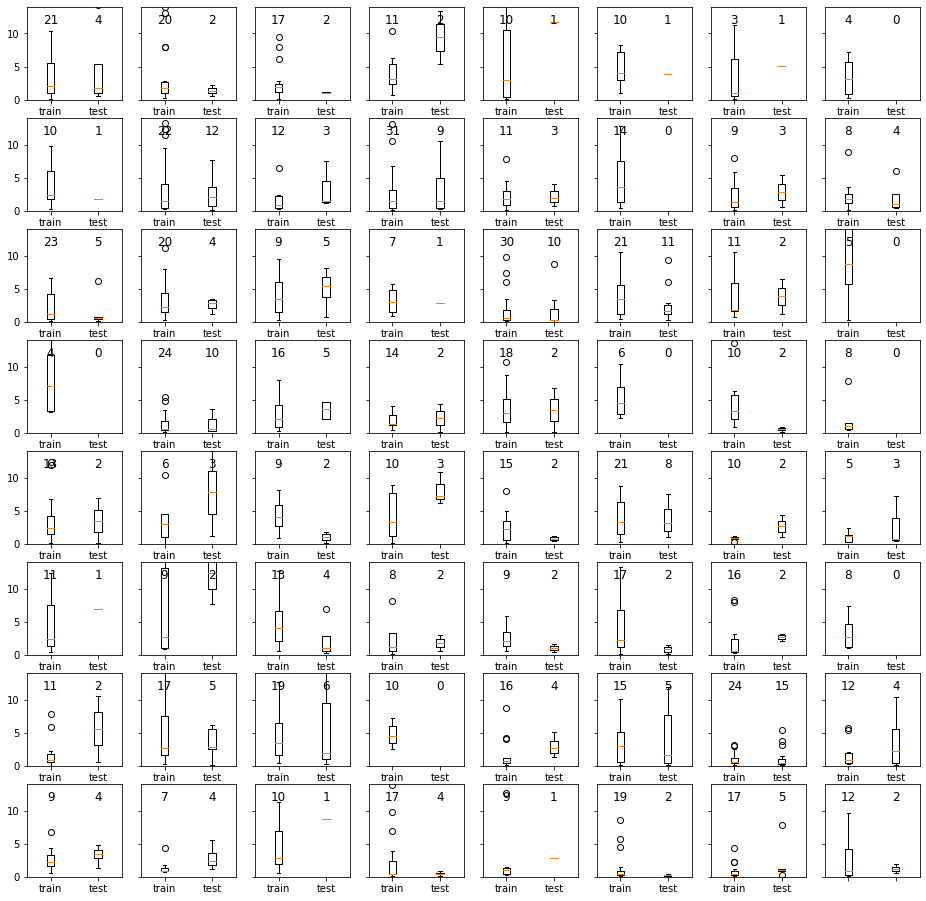

In [60]:
# plot los
fig, ax = plt.subplots(8,8,figsize=(16,16), sharey=True)
plt.xticks(visible=False)

for k in label_map:
    if type(k) is int:
        continue

    los = {
        'train': np.array(label_map[k]['train']['los']), 
        'test': np.array(label_map[k]['test']['los']),
    }
    ax[k[0]][k[1]].boxplot(los.values(), labels=los.keys())
    
    ax[k[0]][k[1]].set_ylim(0, 14)
    
    text_kwargs = dict(ha='center', va='center', fontsize=12, color='black')

    ax[k[0]][k[1]].text(1, 12, f"{len(label_map[k]['train']['los'])}", **text_kwargs)
    ax[k[0]][k[1]].text(2, 12, f"{len(label_map[k]['test']['los'])}", **text_kwargs)

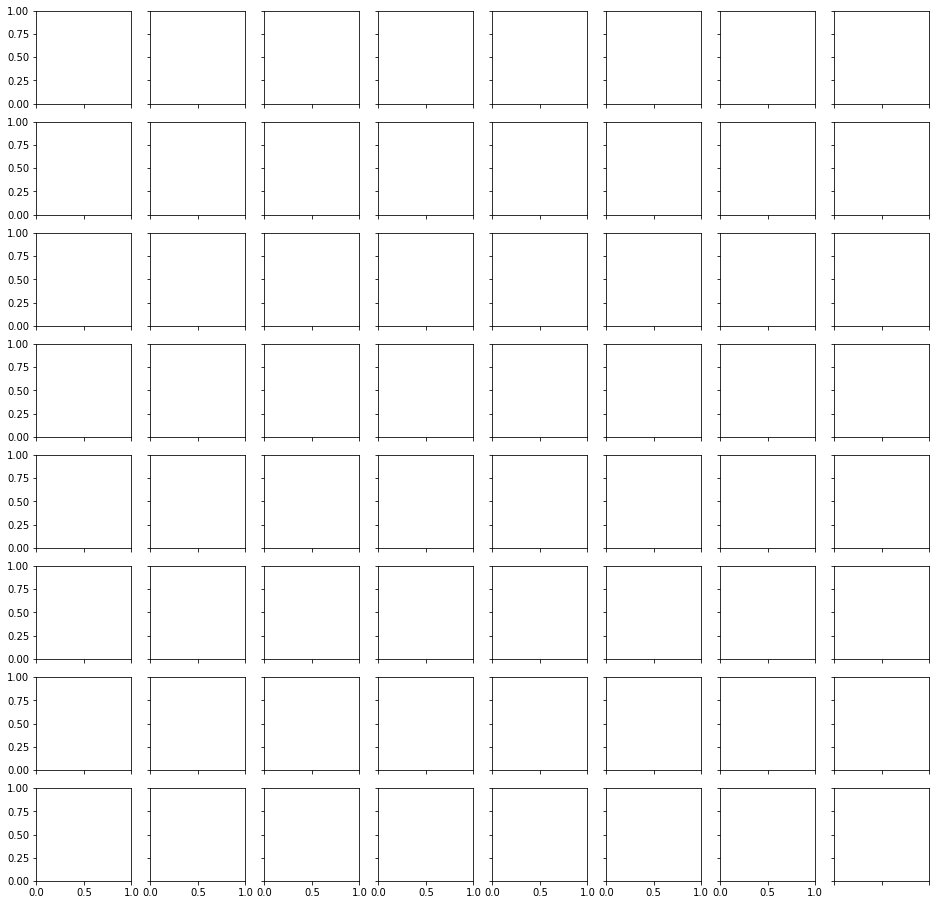

In [48]:
# plot age and mortality
fig, ax = plt.subplots(8,8,figsize=(16,16), sharey=True, sharex=True)
plt.xticks(visible=False)

text_kwargs = dict(ha='center', va='center', fontsize=12, color='black')

for k in label_map:
    try:
        ax[k[0]][k[1]].boxplot(label_map[k]['age'])
        mortality_rate = (label_map[k]['discharge_status']==0).sum() / len(label_map[k]['discharge_status'])
        circ_rate = np.array(label_map[k]['circ_failure']).sum() / len(label_map[k]['circ_failure'])
        resp_rate = np.array(label_map[k]['resp_failure']).sum() / len(label_map[k]['resp_failure'])
        ax[k[0]][k[1]].text(1.3, .9, f'{mortality_rate:.2f}', **text_kwargs)
        ax[k[0]][k[1]].text(1.3, .5, f'{circ_rate:.2f}', **text_kwargs)
        ax[k[0]][k[1]].text(1.3, .1, f'{resp_rate:.2f}', **text_kwargs)
    except:
        continue

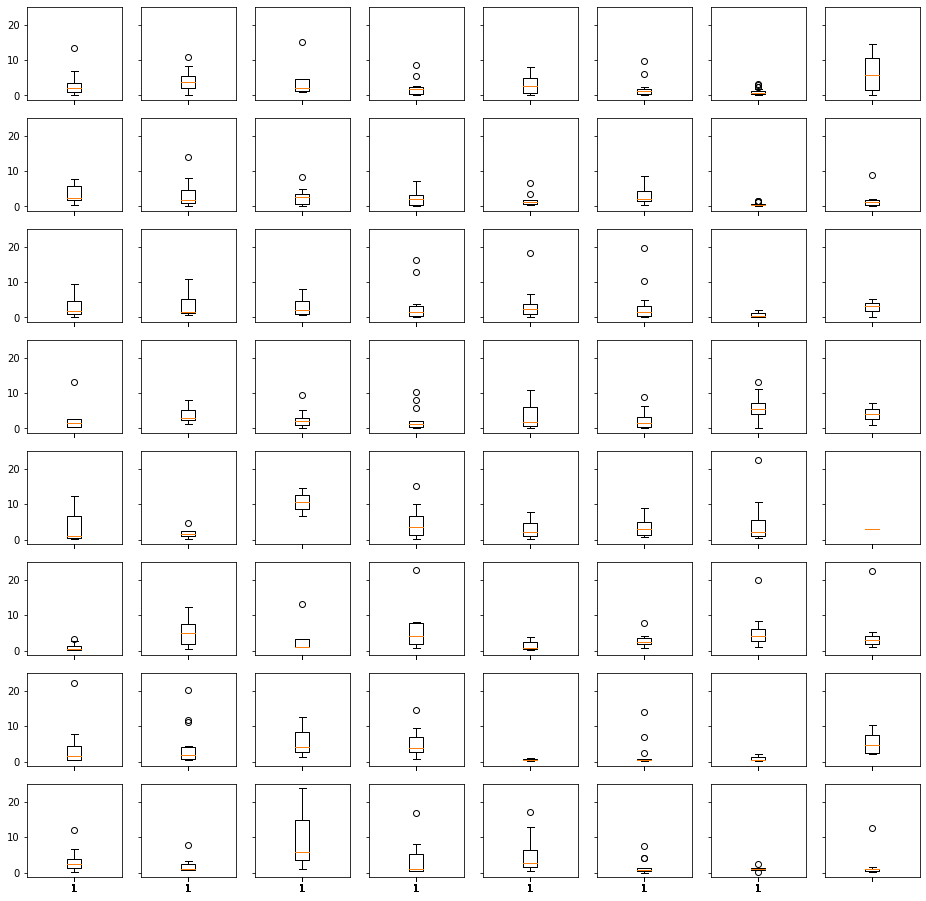

In [64]:
# plot los
fig, ax = plt.subplots(8,8,figsize=(16,16), sharey=True, sharex=True)
plt.xticks(visible=False)

for k in label_map:
    try:
        los = np.array(label_map[k]['los'])
        ax[k[0]][k[1]].boxplot(label_map[k]['los'])
    except:
        continue